# Notebook 09 — Surrogate ligero de muones (θ, p) vía Sliced Wasserstein

Genera un modelo generativo **liviano** (MLP + Sliced Wasserstein Distance, sin
adversarial training) que aprende la distribución conjunta (θ, p) de los muones
simulados por CORSIKA al nivel de observación, inspirado en DeepMuon (Wang et al.
2024, arXiv:2410.06539).

**Alcance honesto (ver memoria `project_ml_decision_2026-07`):** este NO es un
reemplazo de CORSIKA a través de un espacio de parámetros no muestreado. Cada
corrida ya inyecta primarios en **todo** el rango físicamente relevante
(`THETAP 0-89°`, `PHIP 0-360°`, `ERANGE 10 GeV-100 TeV`, ley de potencia
`ESLOPE=-2.7`) — lo único que varía entre corridas es NSHOW. El surrogate es un
**resampler/interpolador estadísticamente eficiente** de la población de muones ya
simulada, útil para suavizar la cola θ>70° (la que más importa para muografía,
ver memoria `project_nshow_recommendations`) donde las corridas individuales
tienen muy pocos muones (verificado abajo: ~9-300 muones en θ∈[70°,90°) por
corrida de 100k showers).

Se rechazó explícitamente replicar un GAN de shower completo (Bozza et al. 2025)
tras una validación con 3 agentes (físico/ML/literatura) — ver la memoria citada
arriba para el razonamiento completo.

Los hiperparámetros del modelo (tamaño de red, learning rate, batch size, número
de proyecciones SWD) se optimizan con **búsqueda bayesiana (Optuna, TPE sampler)**
en la Sección 4 en vez de fijarse a mano.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import torch
import torch.nn as nn

import optuna
import mlflow

from analysis.corsika import CorsikaRun
from analysis.muograma import DEMTerrain, rock_opacity_grid, transmission_map, mc_transmission_map

RNG_SEED = 0
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuración

Editar `MLFLOW_TRACKING_URI` antes de correr — apunta al servidor MLflow externo
(no se levanta nada localmente, no está en docker-compose).

In [5]:
# --- MLflow: servidor externo, se fija manualmente aquí ---
MLFLOW_TRACKING_URI = "http://192.168.20.94"  # <-- editar antes de correr
MLFLOW_EXPERIMENT = "muon_surrogate_lightweight"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# --- Volcán objetivo para la comparación final de transmisión (Sección 6) ---
TARGET_VOLCAN = "fuego"

# --- Corridas a pool-ear para el dataset de entrenamiento ---
# None => usar todas las corridas 'ok' en sim/runs.csv (recomendado en alcyon,
# donde viven las 16 corridas de producción). Poner una lista de RUNNRs para
# restringir (por ejemplo, en el laptop solo hay corridas de prueba de Fuego).
RUNNR_FILTER = None

# --- Directorio para CSVs/PNGs intermedios antes de subirlos a MLflow ---
# Usa el directorio actual (donde vive este notebook) en vez de REPO_ROOT/"ml":
# ese último es un volumen aparte montado en el contenedor y puede quedar con
# permisos de root si Docker lo crea automáticamente. El directorio del
# notebook ya es escribible porque ahí vive el propio archivo .ipynb.
ARTIFACT_DIR = Path.cwd()

## 1. Dataset — pool de muones de las corridas CORSIKA existentes

Todas las corridas comparten la misma configuración física de inyección
(`THETAP 0-89°`, `PHIP 0-360°`, `ERANGE 10 GeV-100 TeV`) — solo varía NSHOW y el
volcán "objetivo" nominal (que no afecta la física de la cascada, solo el
`OBSLEV`/campo geomagnético locales, ver `data/volcanoes.yaml`). Pool-eamos todas
para maximizar estadística de entrenamiento.

In [6]:
runs_csv = pd.read_csv(REPO_ROOT / "sim" / "runs.csv")
ok_runs = runs_csv[runs_csv["status"] == "ok"]
if RUNNR_FILTER is not None:
    ok_runs = ok_runs[ok_runs["runnr"].isin(RUNNR_FILTER)]

print(f"Corridas a pool-ear: {len(ok_runs)}")
print(ok_runs[["runnr", "volcan", "nshow"]].to_string(index=False))

frames = []
for _, run_row in ok_runs.iterrows():
    run = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=int(run_row["runnr"]))
    mu = run.particles.muons()
    frames.append(mu.assign(runnr=int(run_row["runnr"]), volcan=run_row["volcan"]))

muons = pd.concat(frames, ignore_index=True)
p_gevc = np.sqrt(muons["px"] ** 2 + muons["py"] ** 2 + muons["pz"] ** 2)
theta_deg = np.degrees(np.arccos(np.clip(np.abs(muons["pz"]) / p_gevc, -1, 1)))
muons = muons.assign(p_gevc=p_gevc, theta_deg=theta_deg)

print(f"\nTotal de muones pool-eados: {len(muons):,}")

Corridas a pool-ear: 16
 runnr     volcan  nshow
     1      fuego   5000
     2      fuego  10000
     3      fuego  20000
     4      fuego  30000
     5      fuego  50000
     6      fuego 100000
     7 acatenango  50000
     8 acatenango 100000
     9     pacaya  50000
    10     pacaya 100000
    11       agua  50000
    12       agua 100000
    13      fuego 150000
    14 acatenango 150000
    15     pacaya 150000
    16       agua 150000


/opt/conda/lib/python3.11/site-packages/corsikaio/subblocks/run_header.py:84: UserWarning: Version unknown, using run header definition dtype of version 7.x
  warnings.warn("Version unknown, using run header definition dtype of version 7.x")
/opt/conda/lib/python3.11/site-packages/corsikaio/subblocks/event_header.py:144: UserWarning: Version unknown, using event header dtype definition of version 7.7XXX
  warnings.warn("Version unknown, using event header dtype definition of version 7.7XXX")
/opt/conda/lib/python3.11/site-packages/corsikaio/subblocks/event_end.py:46: UserWarning: Version unknown, using default event end definition dtype of version 7.x
  warnings.warn("Version unknown, using default event end definition dtype of version 7.x")



Total de muones pool-eados: 333,979


In [7]:
# Estadística por bin de theta (5°) — evidencia de la cola dispersa que motiva el surrogate
bin_edges = np.arange(0, 95, 5)
counts = pd.cut(muons["theta_deg"], bin_edges).value_counts().sort_index()
print("Muones por bin de θ (5°) — pool completo:")
print(counts.to_string())
print(f"\nθ>70° total: {(muons['theta_deg'] > 70).sum():,} muones "
      f"({(muons['theta_deg'] > 70).mean():.2%} del total)")

Muones por bin de θ (5°) — pool completo:
theta_deg
(0, 5]       5275
(5, 10]     15433
(10, 15]    25097
(15, 20]    32087
(20, 25]    36250
(25, 30]    37954
(30, 35]    37872
(35, 40]    36185
(40, 45]    31406
(45, 50]    25978
(50, 55]    19469
(55, 60]    13895
(60, 65]     8911
(65, 70]     4885
(70, 75]     2278
(75, 80]      804
(80, 85]      172
(85, 90]       28

θ>70° total: 3,282 muones (0.98% del total)


## 2. Split train / val / test — leave-two-out (no un split aleatorio, y no solo 2 vías)

**Nota de honestidad metodológica:** como todas las corridas comparten la misma
configuración física de inyección (`THETAP 0-89°`, `PHIP 0-360°`, `ERANGE 10
GeV-100 TeV`), ningún split puede probar generalización a configuraciones
físicas no muestreadas (otro rango de energía, otro modelo hadrónico, otra
atmósfera) — eso solo se podría evaluar corriendo CORSIKA con una
configuración genuinamente distinta, lo cual queda fuera de alcance de este
notebook (ver memoria `project_ml_decision_2026-07`).

Dicho eso, evitamos la validación más débil posible (un split aleatorio i.i.d.
sobre el pool completo, que solo mide si el modelo resamplea bien los mismos
eventos). En vez de eso, dejamos **dos corridas/volcanes CORSIKA completos e
independientes afuera del entrenamiento**:

- **`val_df`** — usado en la Sección 4 (Optuna) como objetivo a minimizar, y en
  la Sección 5 para la curva train-vs-val (chequeo de overfitting/early
  stopping). Es decir, guía decisiones.
- **`test_df`** — nunca se toca hasta la Sección 6/7. Es el número final que se
  reporta.

Usar el **mismo** conjunto held-out tanto para elegir hiperparámetros como para
reportar el resultado final sería una fuga de información sutil (el resultado
final quedaría optimista, sesgado hacia lo que ese held-out particular
premia) — exactamente la separación train/val/test de 3 vías que es práctica
estándar en ML y que no teníamos antes.

Unidad de holdout: leave-one-volcano-out para val y otro volcano distinto para
test si hay ≥3 volcanes pool-eados (deja ≥2 para entrenar); si no (p. ej. en el
laptop con solo Fuego), leave-two-runs-out a nivel de corrida individual.

In [ ]:
rng = np.random.default_rng(RNG_SEED)
unique_volcanoes = ok_runs["volcan"].unique()

if len(unique_volcanoes) >= 3:
    HOLDOUT_UNIT = "volcano"
    val_value, test_value = rng.choice(unique_volcanoes, size=2, replace=False)
    val_mask = muons["volcan"] == val_value
    test_mask = muons["volcan"] == test_value
else:
    HOLDOUT_UNIT = "run"
    unique_runs = muons["runnr"].unique()
    val_value, test_value = rng.choice(unique_runs, size=2, replace=False)
    val_mask = muons["runnr"] == val_value
    test_mask = muons["runnr"] == test_value

VAL_VALUE, TEST_VALUE = str(val_value), str(test_value)
train_mask = ~(val_mask | test_mask)

val_df = muons[val_mask].reset_index(drop=True)
test_df = muons[test_mask].reset_index(drop=True)
train_df = muons[train_mask].reset_index(drop=True)
print(f"Holdout unit: {HOLDOUT_UNIT}  |  val = {VAL_VALUE!r}  |  test = {TEST_VALUE!r}"
      f"  (leave-two-{HOLDOUT_UNIT}s-out)")
print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")

def to_features(df):
    theta_norm = df["theta_deg"].values / 90.0
    log_p = np.log(df["p_gevc"].values)
    return np.stack([theta_norm, log_p], axis=1).astype(np.float32)

feat_train = to_features(train_df)
feat_val = to_features(val_df)
FEAT_MU, FEAT_SIGMA = feat_train.mean(axis=0), feat_train.std(axis=0)
feat_train_n = (feat_train - FEAT_MU) / FEAT_SIGMA
feat_val_n = (feat_val - FEAT_MU) / FEAT_SIGMA

## 3. Modelo — MLP generador + Sliced Wasserstein Distance

Sin adversarial training: el dataset (~10^5 muones, 2D de salida) no justifica
un GAN ni un Transformer grande — ver memoria `project_ml_decision_2026-07`
(hallazgo del agente ML: "con ~10^5 muones y una sola configuración, un GAN es
sobre-ingeniería"). El tamaño de la red sí se decide por búsqueda bayesiana
(Sección 4), no a mano.

Features: `theta_norm = θ/90°`, `log_p = log(p_gevc)` (el logaritmo reduce la
curtosis del espectro de momento, análogo a la transformación Box-Cox inversa
de DeepMuon), ambas estandarizadas (media 0, var 1) antes de entrenar.

In [9]:
class MuonGenerator(nn.Module):
    """noise -> (theta_norm, log_p) estandarizados."""

    def __init__(self, noise_dim, hidden, n_layers):
        super().__init__()
        self.noise_dim = noise_dim
        layers = [nn.Linear(noise_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


def sliced_wasserstein_distance(x, y, n_proj=64):
    """SWD entre dos batches (N,2): proyecta sobre direcciones aleatorias,
    ordena cada proyección 1D, compara por MSE. Evita el juego minimax de un
    GAN (sin discriminador, sin mode collapse) — ver DeepMuon (arXiv:2410.06539).
    """
    dim = x.shape[1]
    proj = torch.randn(dim, n_proj, device=x.device)
    proj = proj / proj.norm(dim=0, keepdim=True)
    x_sorted, _ = torch.sort(x @ proj, dim=0)
    y_sorted, _ = torch.sort(y @ proj, dim=0)
    return ((x_sorted - y_sorted) ** 2).mean()

## 4. Búsqueda bayesiana de hiperparámetros (Optuna, TPE)

En vez de fijar arquitectura/learning rate a mano, se optimizan con un
`TPESampler` de Optuna. Objetivo a minimizar: la distancia SWD entre una
muestra generada y el **val** (nunca el train ni el test) después de un
entrenamiento corto (`N_EPOCHS_SEARCH`) — barato de evaluar por trial,
suficiente para rankear configuraciones.

Cada trial se registra como una corrida anidada en MLflow (`nested=True`) bajo
la corrida padre `hparam_search`, así queda trazable qué combinaciones se
probaron y por qué se eligió la ganadora.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

feat_train_t = torch.tensor(feat_train_n, device=device)
feat_val_t = torch.tensor(feat_val_n, device=device)

N_TRIALS = 30
N_EPOCHS_SEARCH = 25


def compute_val_swd(gen, noise_dim, n_proj=128):
    with torch.no_grad():
        z = torch.randn(len(feat_val_t), noise_dim, device=device)
        fake_val = gen(z)
        return sliced_wasserstein_distance(fake_val, feat_val_t, n_proj=n_proj).item()


def train_generator(noise_dim, hidden, n_layers, lr, batch_size, n_proj, n_epochs,
                     log_every=None, track_val=False):
    """Entrena un MuonGenerator y devuelve (modelo, historia_train, historia_val).

    `track_val=True` evalúa compute_val_swd() al final de cada época (no solo
    al final del entrenamiento) — la curva train-vs-val resultante es la
    métrica convencional para detectar overfitting, ausente si solo se mira la
    pérdida final. Se deja opcional (False por defecto en la búsqueda de
    hiperparámetros) porque evaluar val en cada época de cada uno de los
    N_TRIALS sería ~2x más caro sin aportar nada a la búsqueda misma.
    """
    gen = MuonGenerator(noise_dim, hidden, n_layers).to(device)
    opt = torch.optim.Adam(gen.parameters(), lr=lr)
    n_batches = max(1, len(feat_train_t) // batch_size)
    train_history, val_history = [], []
    for epoch in range(n_epochs):
        perm = torch.randperm(len(feat_train_t), device=device)
        epoch_losses = []
        for b in range(n_batches):
            real_batch = feat_train_t[perm[b * batch_size:(b + 1) * batch_size]]
            z = torch.randn(len(real_batch), noise_dim, device=device)
            fake_batch = gen(z)
            loss = sliced_wasserstein_distance(fake_batch, real_batch, n_proj=n_proj)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_losses.append(loss.item())
        mean_loss = float(np.mean(epoch_losses))
        train_history.append(mean_loss)
        if track_val:
            val_history.append(compute_val_swd(gen, noise_dim, n_proj=n_proj))
        if log_every and (epoch % log_every == 0 or epoch == n_epochs - 1):
            mlflow.log_metric("train_swd_loss", mean_loss, step=epoch)
            if track_val:
                mlflow.log_metric("val_swd_loss", val_history[-1], step=epoch)
    return gen, train_history, val_history


def objective(trial):
    noise_dim = trial.suggest_int("noise_dim", 4, 32)
    hidden = trial.suggest_categorical("hidden", [32, 64, 128, 256])
    n_layers = trial.suggest_int("n_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512, 1024])
    n_proj = trial.suggest_categorical("n_proj", [16, 32, 64, 128])

    gen, _, _ = train_generator(noise_dim, hidden, n_layers, lr, batch_size, n_proj, N_EPOCHS_SEARCH)
    val_swd = compute_val_swd(gen, noise_dim)
    return val_swd


def mlflow_trial_callback(study, trial):
    with mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True):
        mlflow.log_params(trial.params)
        if trial.value is not None:
            mlflow.log_metric("val_swd", trial.value)


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RNG_SEED))
with mlflow.start_run(run_name="hparam_search") as search_run:
    mlflow.log_params({"n_trials": N_TRIALS, "n_epochs_search": N_EPOCHS_SEARCH})
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[mlflow_trial_callback])
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_val_swd", study.best_value)
    SEARCH_RUN_ID = search_run.info.run_id

print("Mejor combinación encontrada:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"val_swd = {study.best_value:.5f}")

In [ ]:
trials_df = study.trials_dataframe().sort_values("number")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trials_df["number"], trials_df["value"], "o-", alpha=0.7)
ax.axhline(study.best_value, color="red", ls="--", label=f"mejor = {study.best_value:.4f}")
ax.set_xlabel("trial")
ax.set_ylabel("val SWD")
ax.set_title(f"Búsqueda bayesiana de hiperparámetros ({N_TRIALS} trials, TPE sampler)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trials_df[["number", "value"] + [c for c in trials_df.columns if c.startswith("params_")]]

## 5. Entrenamiento final con los mejores hiperparámetros

Se re-entrena con más épocas (`N_EPOCHS_FINAL`) usando `study.best_params`. Esta
corrida (no las de la búsqueda) es la que queda registrada como el "modelo
final" en MLflow, con referencia (`parent_search_run_id`) a la búsqueda que la
produjo para trazabilidad completa.

In [ ]:
N_EPOCHS_FINAL = 300
best = study.best_params

run_name = f"{TARGET_VOLCAN}_mlp_swd_final_{len(muons)}muons"
with mlflow.start_run(run_name=run_name) as final_run:
    mlflow.log_params({
        **best,
        "n_epochs_final": N_EPOCHS_FINAL,
        "n_muons_total": len(muons), "n_muons_train": len(train_df),
        "n_muons_val": len(val_df), "n_muons_test": len(test_df),
        "runs_pooled": ",".join(map(str, ok_runs["runnr"])),
        "holdout_unit": HOLDOUT_UNIT, "val_value": VAL_VALUE, "test_value": TEST_VALUE,
        "device": str(device), "seed": RNG_SEED,
        "parent_search_run_id": SEARCH_RUN_ID,
    })

    gen, loss_history, val_history = train_generator(
        best["noise_dim"], best["hidden"], best["n_layers"], best["lr"],
        best["batch_size"], best["n_proj"], N_EPOCHS_FINAL, log_every=5,
        track_val=True,
    )
    final_val_swd = val_history[-1]
    mlflow.log_metric("final_val_swd", final_val_swd)
    MLRUN_ID = final_run.info.run_id

print(f"MLflow run_id (modelo final): {MLRUN_ID}")
print(f"val_swd final: {final_val_swd:.5f}  (búsqueda: {study.best_value:.5f})")

# --- Curva train vs val — chequeo convencional de overfitting ---
# Si val se estanca o empieza a subir mientras el train sigue bajando, el
# modelo está memorizando el train en vez de aprender la distribución. DeepMuon
# (arXiv:2410.06539) reporta este mismo riesgo de forma cualitativa ("halt
# training before the model overfits") sin un criterio numérico — acá sí lo
# medimos con la curva y una regla explícita.
best_epoch = int(np.argmin(val_history))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(loss_history, label="train", color="tab:blue")
ax.plot(val_history, label="val", color="tab:orange")
ax.axvline(best_epoch, color="gray", ls=":", alpha=0.7,
           label=f"mejor val (epoch {best_epoch})")
ax.set_xlabel("epoch")
ax.set_ylabel("Sliced Wasserstein loss")
ax.set_yscale("log")
ax.set_title("Train vs. val — chequeo de overfitting")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = val_history[-1] - loss_history[-1]
gap_at_best = val_history[best_epoch] - loss_history[best_epoch]
print(f"\nSWD train final: {loss_history[-1]:.5f}")
print(f"SWD val final:    {val_history[-1]:.5f}  (gap = {gap:+.5f})")
print(f"SWD val mínimo:   {val_history[best_epoch]:.5f}  en epoch {best_epoch}"
      f"  (gap en ese punto = {gap_at_best:+.5f})")
if best_epoch < N_EPOCHS_FINAL - 1 and val_history[-1] > 1.2 * val_history[best_epoch]:
    print(f"⚠ El val mejoró hasta la época {best_epoch} y luego empeoró >20% — "
          f"señal de overfitting; considerar early stopping en esa época.")
else:
    print("El val no muestra un deterioro claro después del mejor punto — "
          "no hay señal fuerte de overfitting con este número de épocas.")

## 5b. Arquitectura del modelo entrenado

Resumen de capas/parámetros y diagrama de la red, generados a partir de los
hiperparámetros reales elegidos por Optuna (no hardcodeados).

In [13]:
n_params = sum(p.numel() for p in gen.parameters())
n_trainable = sum(p.numel() for p in gen.parameters() if p.requires_grad)
print(gen)
print(f"\nParámetros totales:     {n_params:,}")
print(f"Parámetros entrenables: {n_trainable:,}")
print(f"Ratio parámetros/muón de entrenamiento: {n_params / len(train_df):.4f} "
      f"(bajo => poco riesgo de memorizar el train)")

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_metric("n_params", n_params)

MuonGenerator(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

Parámetros totales:     1,858
Parámetros entrenables: 1,858
Ratio parámetros/muón de entrenamiento: 0.0072 (bajo => poco riesgo de memorizar el train)
🏃 View run fuego_mlp_swd_final_333979muons at: http://192.168.20.94/#/experiments/3/runs/7fd56e3a183e4f76ac3a9b8b3f3c3dc1
🧪 View experiment at: http://192.168.20.94/#/experiments/3


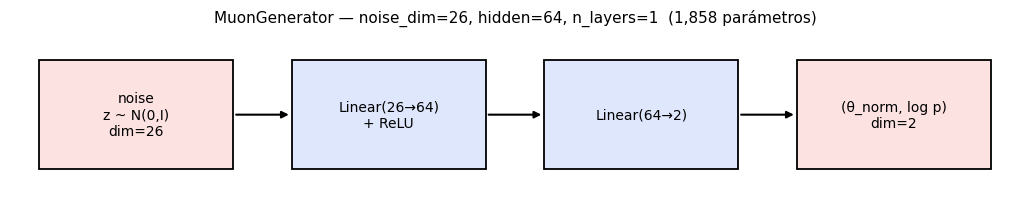

🏃 View run fuego_mlp_swd_final_333979muons at: http://192.168.20.94/#/experiments/3/runs/7fd56e3a183e4f76ac3a9b8b3f3c3dc1
🧪 View experiment at: http://192.168.20.94/#/experiments/3


In [14]:
def draw_mlp_architecture(noise_dim, hidden, n_layers, out_dim=2):
    """Diagrama de bloques del MuonGenerator, con las dimensiones reales
    elegidas por Optuna (no un diagrama genérico)."""
    boxes = [f"noise\nz ~ N(0,I)\ndim={noise_dim}"]
    for i in range(n_layers):
        in_dim = noise_dim if i == 0 else hidden
        boxes.append(f"Linear({in_dim}→{hidden})\n+ ReLU")
    boxes.append(f"Linear({hidden}→{out_dim})")
    boxes.append(f"(θ_norm, log p)\ndim={out_dim}")

    fig, ax = plt.subplots(figsize=(2.6 * len(boxes), 2.2))
    box_w, box_h = 2.0, 1.1
    xs = np.arange(len(boxes)) * 2.6

    for x, label in zip(xs, boxes):
        is_io = label.startswith("noise") or label.startswith("(θ")
        ax.add_patch(plt.Rectangle(
            (x, 0), box_w, box_h,
            facecolor="#dfe7fd" if not is_io else "#fde2e2",
            edgecolor="black", lw=1.3,
        ))
        ax.text(x + box_w / 2, box_h / 2, label, ha="center", va="center", fontsize=10)

    for x in xs[:-1]:
        ax.annotate("", xy=(x + 2.6, box_h / 2), xytext=(x + box_w, box_h / 2),
                    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black"))

    ax.set_xlim(-0.3, xs[-1] + box_w + 0.3)
    ax.set_ylim(-0.3, box_h + 0.3)
    ax.axis("off")
    ax.set_title(
        f"MuonGenerator — noise_dim={noise_dim}, hidden={hidden}, n_layers={n_layers}"
        f"  ({n_params:,} parámetros)",
        fontsize=11,
    )
    plt.tight_layout()
    return fig


arch_fig = draw_mlp_architecture(best["noise_dim"], best["hidden"], best["n_layers"])
arch_fig_path = ARTIFACT_DIR / "surrogate_architecture.png"
arch_fig.savefig(arch_fig_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(arch_fig_path))

## 6. Evaluación detallada contra el test

Todas las métricas se imprimen/grafican aquí **y** se registran en MLflow
(`mlflow.log_metric`, tablas como artifact CSV, figuras como artifact PNG) para
que el experimento quede completamente trazable desde la UI. `test_df` nunca
se usó para entrenar ni para elegir hiperparámetros (eso fue `val_df`,
Secciones 4-5) — este es el número que se reporta.

In [ ]:
N_SYNTH = 2_000_000  # samplear del generador ya entrenado es casi gratis (a diferencia de correr
                      # más CORSIKA) — usamos muchas más muestras que el tamaño del test real
                      # para que la comparación de cobertura en la cola (Sección 7) sea justa.
NOISE_DIM_BEST = best["noise_dim"]
with torch.no_grad():
    z = torch.randn(N_SYNTH, NOISE_DIM_BEST, device=device)
    synth_n = gen(z).cpu().numpy()
synth = synth_n * FEAT_SIGMA + FEAT_MU
synth_theta = np.clip(synth[:, 0] * 90.0, 0, 90)
synth_p = np.exp(synth[:, 1])

ks_theta = stats.ks_2samp(test_df["theta_deg"].values, synth_theta)
ks_p = stats.ks_2samp(test_df["p_gevc"].values, synth_p)
print(f"KS global theta:  stat={ks_theta.statistic:.4f}  p-value={ks_theta.pvalue:.3g}")
print(f"KS global p_gevc: stat={ks_p.statistic:.4f}  p-value={ks_p.pvalue:.3g}")

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_metric("ks_theta_global_stat", ks_theta.statistic)
    mlflow.log_metric("ks_theta_global_pvalue", ks_theta.pvalue)
    mlflow.log_metric("ks_p_global_stat", ks_p.statistic)
    mlflow.log_metric("ks_p_global_pvalue", ks_p.pvalue)

In [ ]:
# Comparación visual directa real (test) vs sintético — la evaluación más
# intuitiva y "convencional" para un modelo generativo, ausente si solo se
# mira el KS test como número.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(test_df["theta_deg"], bins=60, density=True, alpha=0.5, label="real (test)", color="tab:orange")
axes[0].hist(synth_theta, bins=60, density=True, alpha=0.5, label="sintético", color="tab:blue")
axes[0].set_xlabel("θ [°]"); axes[0].set_ylabel("densidad")
axes[0].set_title("Marginal θ")
axes[0].legend()

axes[1].hist(test_df["p_gevc"], bins=np.logspace(-1, 3, 60), density=True, alpha=0.5,
             label="real (test)", color="tab:orange")
axes[1].hist(synth_p, bins=np.logspace(-1, 3, 60), density=True, alpha=0.5,
             label="sintético", color="tab:blue")
axes[1].set_xscale("log"); axes[1].set_xlabel("p [GeV/c]"); axes[1].set_ylabel("densidad")
axes[1].set_title("Marginal p (escala log)")
axes[1].legend()

# Q-Q plot de p — compara cuantiles directamente, más sensible a la cola que un histograma
qs = np.linspace(0.01, 0.99, 100)
q_real = np.quantile(test_df["p_gevc"].values, qs)
q_synth = np.quantile(synth_p, qs)
axes[2].plot(q_real, q_synth, "o", ms=3, alpha=0.6, color="tab:green")
lims = [0, max(q_real.max(), q_synth.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5, label="identidad")
axes[2].set_xlabel("cuantiles p — real (test)")
axes[2].set_ylabel("cuantiles p — sintético")
axes[2].set_title("Q-Q plot de p (1er-99o percentil)")
axes[2].legend()

plt.tight_layout()
dist_fig_path = ARTIFACT_DIR / "surrogate_distribution_overlay.png"
fig.savefig(dist_fig_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(dist_fig_path))

## 6b. Robustez con datos limitados (estilo Fig. 4 de DeepMuon)

DeepMuon (arXiv:2410.06539, Fig. 4) entrena su modelo con solo 6,000 muestras de
CRY (vs. su dataset completo de 100 millones) para mostrar que aprende bien la
distribución incluso con muy poco dato — un argumento directamente relevante
para nuestro caso, ya que el pool de entrenamiento (~250k-2.7M muones según el
volcán/laptop) es igual de modesto frente a un dataset de producción real.

Reproducimos el mismo experimento: entrenamos un segundo generador con los
mismos hiperparámetros (de Optuna) pero usando solo `LIMITED_N` muones
sampleados del train, y comparamos ambos (dataset completo vs. limitado) contra
el mismo `test_df` nunca visto — reutilizando `synth_theta`/`synth_p` (el
modelo completo) ya generados arriba.

In [ ]:
LIMITED_N = min(6_000, len(train_df))  # mismo tamaño que el experimento de DeepMuon
limited_idx = rng.choice(len(train_df), size=LIMITED_N, replace=False)
feat_train_limited_n = (to_features(train_df.iloc[limited_idx]) - FEAT_MU) / FEAT_SIGMA
feat_train_limited_t = torch.tensor(feat_train_limited_n, device=device)

# Reusa train_generator pero apuntando temporalmente feat_train_t al subset limitado
_feat_train_t_full_backup = feat_train_t
feat_train_t = feat_train_limited_t
with mlflow.start_run(run_name=f"{TARGET_VOLCAN}_mlp_swd_limited_{LIMITED_N}muons"):
    mlflow.log_params({**best, "n_epochs_final": N_EPOCHS_FINAL, "n_muons_train": LIMITED_N})
    gen_limited, loss_history_limited, _ = train_generator(
        best["noise_dim"], best["hidden"], best["n_layers"], best["lr"],
        min(best["batch_size"], LIMITED_N), best["n_proj"], N_EPOCHS_FINAL,
    )
feat_train_t = _feat_train_t_full_backup  # restaurar para el resto del notebook

with torch.no_grad():
    z = torch.randn(200_000, best["noise_dim"], device=device)
    synth_limited_n = gen_limited(z).cpu().numpy()
synth_limited = synth_limited_n * FEAT_SIGMA + FEAT_MU
synth_limited_theta = np.clip(synth_limited[:, 0] * 90.0, 0, 90)
synth_limited_p = np.exp(synth_limited[:, 1])

print(f"Entrenado con dataset completo: {len(train_df):,} muones")
print(f"Entrenado con dataset limitado: {LIMITED_N:,} muones")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(test_df["theta_deg"], bins=60, density=True, alpha=0.45, label="real (test)", color="black")
axes[0].hist(synth_theta, bins=60, density=True, histtype="step", lw=2,
             label=f"sintético — dataset completo ({len(train_df):,})", color="tab:blue")
axes[0].hist(synth_limited_theta, bins=60, density=True, histtype="step", lw=2,
             label=f"sintético — dataset limitado ({LIMITED_N:,})", color="tab:red")
axes[0].set_xlabel("θ [°]"); axes[0].set_ylabel("densidad")
axes[0].set_title("Marginal θ — completo vs. limitado")
axes[0].legend(fontsize=8)

bins_p = np.logspace(-1, 3, 60)
axes[1].hist(test_df["p_gevc"], bins=bins_p, density=True, alpha=0.45, label="real (test)", color="black")
axes[1].hist(synth_p, bins=bins_p, density=True, histtype="step", lw=2,
             label=f"sintético — dataset completo ({len(train_df):,})", color="tab:blue")
axes[1].hist(synth_limited_p, bins=bins_p, density=True, histtype="step", lw=2,
             label=f"sintético — dataset limitado ({LIMITED_N:,})", color="tab:red")
axes[1].set_xscale("log"); axes[1].set_xlabel("p [GeV/c]"); axes[1].set_ylabel("densidad")
axes[1].set_title("Marginal p — completo vs. limitado")
axes[1].legend(fontsize=8)

plt.tight_layout()
limited_fig_path = ARTIFACT_DIR / "surrogate_limited_data_comparison.png"
fig.savefig(limited_fig_path, dpi=150, bbox_inches="tight")
plt.show()

ks_theta_limited = stats.ks_2samp(test_df["theta_deg"].values, synth_limited_theta)
ks_p_limited = stats.ks_2samp(test_df["p_gevc"].values, synth_limited_p)
print(f"{'':20s} {'KS theta':>12s} {'KS p':>12s}")
print(f"{'dataset completo':20s} {ks_theta.statistic:>12.4f} {ks_p.statistic:>12.4f}")
print(f"{'dataset limitado':20s} {ks_theta_limited.statistic:>12.4f} {ks_p_limited.statistic:>12.4f}")

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(limited_fig_path))
    mlflow.log_metric("ks_theta_limited_data", ks_theta_limited.statistic)
    mlflow.log_metric("ks_p_limited_data", ks_p_limited.statistic)

## 6c. Cortes por ángulo (estilo Fig. 3 de DeepMuon)

DeepMuon (Fig. 3) muestra la distribución de energía en tres cortes: todos los
eventos, θ=1°, y θ=60°. Replicamos la idea con tres cortes representativos de
nuestro caso: una región bien poblada (θ≈10°), una intermedia (θ≈45°), y la
cola θ≈75° que motiva este notebook — donde menos estadística real hace más
difícil (y más importante) que el ajuste sea bueno.

In [ ]:
theta_slices = [
    (5, 15, "θ∈[5°,15°) — bien poblada"),
    (40, 50, "θ∈[40°,50°) — intermedia"),
    (70, 80, "θ∈[70°,80°) — cola (motivación)"),
]

fig, axes = plt.subplots(1, len(theta_slices), figsize=(16, 4.5))
bins_p = np.logspace(-1, 3, 40)
for ax, (lo, hi, label) in zip(axes, theta_slices):
    real_mask = (test_df["theta_deg"] >= lo) & (test_df["theta_deg"] < hi)
    synth_mask = (synth_theta >= lo) & (synth_theta < hi)
    n_real, n_synth = int(real_mask.sum()), int(synth_mask.sum())
    ax.hist(test_df.loc[real_mask, "p_gevc"], bins=bins_p, density=True, alpha=0.5,
            label=f"real (n={n_real})", color="tab:orange")
    ax.hist(synth_p[synth_mask], bins=bins_p, density=True, alpha=0.5,
            label=f"sintético (n={n_synth})", color="tab:blue")
    ax.set_xscale("log")
    ax.set_xlabel("p [GeV/c]")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel("densidad")
plt.suptitle("Distribución de momento por corte de θ — real (test) vs sintético", y=1.03)
plt.tight_layout()
angle_slice_fig_path = ARTIFACT_DIR / "surrogate_angle_slices.png"
fig.savefig(angle_slice_fig_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(angle_slice_fig_path))

In [ ]:
def per_bin_evaluation(test_df, synth_theta, synth_p, bin_width=5.0, theta_max=90.0, min_n=20):
    """KS test + cuantiles p95/p99 de p(p|theta) por bin — real (test) vs sintético.
    Los bins con pocas muestras reales (la cola theta>70 que motiva este notebook)
    se marcan explícitamente como 'insuficiente' en vez de reportar un KS engañoso.
    """
    rows = []
    edges = np.arange(0, theta_max + bin_width, bin_width)
    for lo, hi in zip(edges[:-1], edges[1:]):
        real_mask = (test_df["theta_deg"] >= lo) & (test_df["theta_deg"] < hi)
        synth_mask = (synth_theta >= lo) & (synth_theta < hi)
        n_real, n_synth = int(real_mask.sum()), int(synth_mask.sum())
        row = {"theta_lo": lo, "theta_hi": hi, "n_real_test": n_real, "n_synth": n_synth}
        if n_real < min_n or n_synth < min_n:
            row.update(ks_stat=np.nan, ks_pvalue=np.nan, p95_real=np.nan, p95_synth=np.nan,
                       p99_real=np.nan, p99_synth=np.nan, status="insuficiente")
        else:
            real_p = test_df.loc[real_mask, "p_gevc"].values
            syn_p = synth_p[synth_mask]
            ks = stats.ks_2samp(real_p, syn_p)
            row.update(
                ks_stat=ks.statistic, ks_pvalue=ks.pvalue,
                p95_real=np.percentile(real_p, 95), p95_synth=np.percentile(syn_p, 95),
                p99_real=np.percentile(real_p, 99), p99_synth=np.percentile(syn_p, 99),
                status="ok",
            )
        rows.append(row)
    return pd.DataFrame(rows)


eval_table = per_bin_evaluation(test_df, synth_theta, synth_p, bin_width=5.0)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
eval_table

In [ ]:
eval_csv_path = ARTIFACT_DIR / "surrogate_eval_table.csv"
eval_table.to_csv(eval_csv_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ok = eval_table["status"] == "ok"
mid = (eval_table["theta_lo"] + eval_table["theta_hi"]) / 2

axes[0].bar(mid[ok], eval_table.loc[ok, "ks_stat"], width=4, color="tab:blue", alpha=0.7)
axes[0].axvline(70, color="red", ls="--", label="θ=70° (umbral muografía)")
axes[0].set_xlabel("θ [°]"); axes[0].set_ylabel("KS statistic (p | θ)")
axes[0].set_title("Distancia KS por bin — test vs sintético")
axes[0].legend()

axes[1].bar(mid, eval_table["n_real_test"], width=2, alpha=0.6, label="real (test)")
axes[1].bar(mid, eval_table["n_synth"], width=2, alpha=0.4, label="sintético")
axes[1].axvline(70, color="red", ls="--")
axes[1].set_yscale("log")
axes[1].set_xlabel("θ [°]"); axes[1].set_ylabel("N muones (log)")
axes[1].set_title("Estadística disponible por bin")
axes[1].legend()

plt.tight_layout()
fig_path = ARTIFACT_DIR / "surrogate_eval_plot.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(eval_csv_path))
    mlflow.log_artifact(str(fig_path))
    ok_rows = eval_table[eval_table["status"] == "ok"]
    mlflow.log_metric("ks_stat_mean_ok_bins", ok_rows["ks_stat"].mean())
    mlflow.log_metric("n_bins_insuficientes", (eval_table["status"] == "insuficiente").sum())
    tail = eval_table[eval_table["theta_lo"] >= 70]
    mlflow.log_metric("n_bins_tail_theta70_insuficientes", (tail["status"] == "insuficiente").sum())

## 7. Comparación de mapas de transmisión: T_dem (Reyna) vs T_mc (real) vs T_surrogate

Reutiliza `mc_transmission_map` (la misma función que usa NB05/NB07 en el
pipeline no-ML) pero alimentada con la muestra **sintética** en vez de la muestra
MC real — así el surrogate se evalúa en la cantidad física que realmente importa
(la transmisión angular usada para el muograma), no solo en KS abstracto.

In [19]:
import yaml
from pyproj import Transformer

with open(REPO_ROOT / "data" / "volcanoes.yaml") as f:
    volcan_cfg = yaml.safe_load(f)[TARGET_VOLCAN]
station_name = volcan_cfg["default_station"]

dem_file = REPO_ROOT / "data" / "dem" / "Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif"
terrain = DEMTerrain(dem_file, origin_lonlat=(volcan_cfg["lon"], volcan_cfg["lat"]),
                      density_gcc=volcan_cfg["cone"]["density_gcc"])

sites = pd.read_csv(REPO_ROOT / "data" / "detector_sites.csv")
site = sites[(sites["name"] == station_name) & (sites["target_volcan"] == TARGET_VOLCAN)].iloc[0]
tx = Transformer.from_crs("EPSG:4326", f"EPSG:{terrain.utm_epsg}", always_xy=True)
e_utm, n_utm = tx.transform(site["lon"], site["lat"])
det_x = float(e_utm - terrain.origin_utm[0])
det_y = float(n_utm - terrain.origin_utm[1])
det_z = float(terrain.elevation_at(np.array(det_x), np.array(det_y))) + 2.0
detector_xyz = (det_x, det_y, det_z)

phi_summit_deg = np.degrees(np.arctan2(-det_y, -det_x)) % 360.0

theta_deg_grid = np.arange(40.0, 85.5, 0.5)
phi_deg_grid = np.arange(phi_summit_deg - 60, phi_summit_deg + 60.5, 0.5)
theta_rad_grid = np.radians(theta_deg_grid)
phi_rad_grid = np.radians(phi_deg_grid)

L_dem = rock_opacity_grid(terrain, detector_xyz, theta_rad_grid, phi_rad_grid,
                           max_length_m=8_000.0, n_steps=400)
T_dem = transmission_map(L_dem, theta_rad_grid)
T_mc = mc_transmission_map(L_dem, theta_rad_grid, muons, theta_bin_width_deg=5.0, min_per_bin=50)

synth_df = pd.DataFrame({"p_gevc": synth_p, "theta_deg": synth_theta})
T_surrogate = mc_transmission_map(L_dem, theta_rad_grid, synth_df, theta_bin_width_deg=5.0, min_per_bin=50)

for name, T in [("T_dem (Reyna analítico)", T_dem), ("T_mc (MC real)", T_mc), ("T_surrogate", T_surrogate)]:
    valid = np.isfinite(T)
    print(f"{name:26s}  cobertura={valid.mean():.1%}  media={np.nanmean(T):.3f}")

T_dem (Reyna analítico)     cobertura=100.0%  media=0.667
T_mc (MC real)              cobertura=98.9%  media=0.674
T_surrogate                 cobertura=98.9%  media=0.673


--- Cola θ>70° (la región que el surrogate debería mejorar) ---
     modelo  cobertura_tail  media_tail  bias_vs_T_dem
      T_dem           1.000       0.121          0.000
       T_mc           0.967       0.125          0.004
T_surrogate           0.967       0.122          0.001


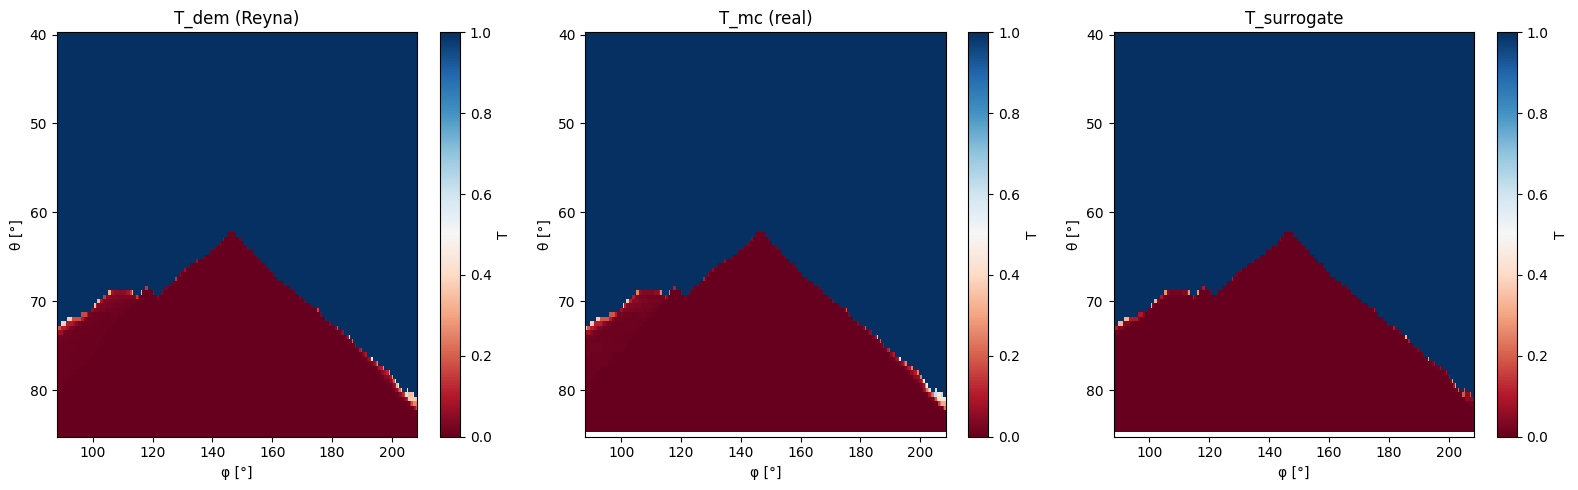

🏃 View run fuego_mlp_swd_final_333979muons at: http://192.168.20.94/#/experiments/3/runs/7fd56e3a183e4f76ac3a9b8b3f3c3dc1
🧪 View experiment at: http://192.168.20.94/#/experiments/3


In [20]:
tail_mask = np.broadcast_to((theta_deg_grid > 70)[:, None], T_dem.shape)
print("--- Cola θ>70° (la región que el surrogate debería mejorar) ---")
rows = []
for name, T in [("T_dem", T_dem), ("T_mc", T_mc), ("T_surrogate", T_surrogate)]:
    vals = T[tail_mask]
    valid = np.isfinite(vals)
    bias_vs_dem = np.nanmean(vals) - np.nanmean(T_dem[tail_mask])
    rows.append({
        "modelo": name, "cobertura_tail": valid.mean(),
        "media_tail": np.nanmean(vals), "bias_vs_T_dem": bias_vs_dem,
    })
tail_summary = pd.DataFrame(rows)
print(tail_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PHI, THETA = np.meshgrid(phi_deg_grid, theta_deg_grid)
for ax, T, title in [(axes[0], T_dem, "T_dem (Reyna)"), (axes[1], T_mc, "T_mc (real)"),
                      (axes[2], T_surrogate, "T_surrogate")]:
    im = ax.pcolormesh(PHI, THETA, T, cmap="RdBu", shading="auto", vmin=0,vmax=1)
    ax.invert_yaxis()
    ax.set_xlabel("φ [°]"); ax.set_ylabel("θ [°]")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="T")
plt.tight_layout()
transmission_fig_path = ARTIFACT_DIR / "surrogate_transmission_comparison.png"
fig.savefig(transmission_fig_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=MLRUN_ID):
    mlflow.log_artifact(str(transmission_fig_path))
    tail_csv_path = ARTIFACT_DIR / "surrogate_tail_summary.csv"
    tail_summary.to_csv(tail_csv_path, index=False)
    mlflow.log_artifact(str(tail_csv_path))
    mlflow.log_metric("tail_coverage_T_mc", tail_summary.loc[tail_summary['modelo'] == 'T_mc', 'cobertura_tail'].iloc[0])
    mlflow.log_metric("tail_coverage_T_surrogate", tail_summary.loc[tail_summary['modelo'] == 'T_surrogate', 'cobertura_tail'].iloc[0])
    mlflow.log_metric("tail_bias_T_mc", tail_summary.loc[tail_summary['modelo'] == 'T_mc', 'bias_vs_T_dem'].iloc[0])
    mlflow.log_metric("tail_bias_T_surrogate", tail_summary.loc[tail_summary['modelo'] == 'T_surrogate', 'bias_vs_T_dem'].iloc[0])

## 8. Conclusiones — qué SÍ y qué NO demuestra este notebook

**Sí demuestra (si las métricas de arriba salen razonables):**
- Un surrogate liviano (MLP + SWD, hiperparámetros elegidos por búsqueda
  bayesiana, sin GAN), validado con un split de **3 vías train/val/test**
  (leave-two-out por volcán/corrida, no un split i.i.d. y no solo 2 vías —
  Sección 2), puede aumentar la cobertura de píxeles válidos en el mapa de
  transmisión en la cola θ>70° respecto al MC crudo (comparar `cobertura_tail`
  de `T_surrogate` vs `T_mc` arriba), y puede acercar el sesgo de esa cola
  hacia el valor analítico de Reyna (`bias_vs_T_dem`).
- El modelo reproduce razonablemente la distribución conjunta (θ, p) en las
  regiones con buena estadística (KS no rechazado en la mayoría de bins con
  θ<60°), evaluado contra `test_df` — una corrida/volcán que nunca se usó ni
  para entrenar ni para elegir hiperparámetros (eso fue `val_df`).
- El chequeo de overfitting (Sección 5) usa un criterio numérico explícito
  sobre la curva train-vs-val, en vez del criterio cualitativo ("se para a
  ojo") que reporta DeepMuon para el mismo riesgo con los artefactos
  escalonados de CRY.
- Las Secciones 5b/6b/6c replican directamente las Figs. 2, 4 y 3 de DeepMuon
  (arquitectura con dimensiones reales, robustez con dataset limitado a 6,000
  muones, cortes de momento por bin de θ) para este surrogate.

**NO demuestra (y no se debe afirmar en el paper):**
- Que el surrogate generalice a configuraciones físicas no muestreadas
  (energía primaria fuera de `ERANGE`, otro modelo hadrónico, otra atmósfera)
  — todas las corridas usadas comparten la misma configuración de inyección;
  el leave-two-out de la Sección 2 prueba generalización entre *realizaciones*
  de MC independientes, no entre *configuraciones* físicas distintas. Para
  eso haría falta correr CORSIKA con parámetros genuinamente distintos.
- Que sea más preciso que correr más CORSIKA — es una alternativa cuando correr
  más CORSIKA no es práctico (p. ej. explorar muchos sitios de detector sin
  volver a simular), no una mejora de exactitud per se.

Revisar `eval_table` y `tail_summary` completos arriba para decidir si el
resultado es lo bastante sólido para incluirse como capítulo secundario del
Paper 2, o si hace falta más data (correr sobre las 16 corridas de producción
en alcyon, no solo las pruebas locales de Fuego).